<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/graph5_human_in_the_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph 5 - Human in the Loop
The graph looks up the salary of an employee and calculates the tax to pay. The salary lookup requires human approval

In [1]:
!pip install langgraph --quiet

In [2]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [3]:
class State(TypedDict):
  employee: str
  salary: float
  tax: float
  approval: Literal['pending', 'approved', 'rejected']

In [4]:
salaries = {
    "Tim": 100000,
    "Tom": 90000,
    "Ann": 120000
}

In [9]:
def get_valid_name(state: State) -> State:
  """Initialize approval state and prompt for employee name"""
  employee = input("Enter an employee name (Tim/Tom/Ann): ")
  state['employee'] = employee.strip()
  state['approval'] = 'pending'
  return state
#print(start_node({}))

def valid_employee(state: State) -> bool:
  """Check if employee is valid"""
  return state['employee'] in salaries
#print(valid_employee({"employee": "Tim"}))

def approval_node(state: State) -> State:
  """Seeks human approval to lookup salary"""
  response = input(f"Do you give me your approval to retrieve the salary for employee: {state['employee']} (y/n)")
  if response == 'y':
    state['approval'] = 'approved'
  else:
    state['approval'] = 'rejected'
  return state
#print(approval_node({"employee": "Tim", "approval": "pending"}))

def router(state:State) -> str:
  """routes flow based on approval"""
  if state['approval'] == 'approved':
    return 'get_salary'
  else:
    return 'end'
#print(router({"employee": "Tim", "approval": "rejected"}))
#print(router({"employee": "Tim", "approval": "approved"}))

def salary_node(state: State) -> State:
  """Retrieves salary"""
  state['salary'] = salaries[state["employee"]]
  return state
#print(salary_node({"employee": "Tim", "approval": "approved"}))

def get_tax_node(state: State) -> State:
  """Calculates tax"""
  state['tax'] = state['salary'] * 0.2
  return state
#print(get_tax_node({"employee": "Tim", "approval": "approved", "salary": 100000}))


In [10]:
graph = StateGraph(State)
# NODES
graph.add_node("get_valid_name", get_valid_name)
graph.add_node("approval_node", approval_node)
graph.add_node("get_salary_node", salary_node)
graph.add_node("get_tax_node", get_tax_node)
# EDGES
graph.add_edge(START, "get_valid_name")
graph.add_conditional_edges(
    "get_valid_name",
    valid_employee,
    {
        True: "approval_node",
        False: "get_valid_name"
    })
graph.add_conditional_edges(
    "approval_node",
    router,
    {
        "get_salary": "get_salary_node",
        "end": END
    })
graph.add_edge("get_salary_node", "get_tax_node")
graph.add_edge("get_tax_node", END)
app = graph.compile()


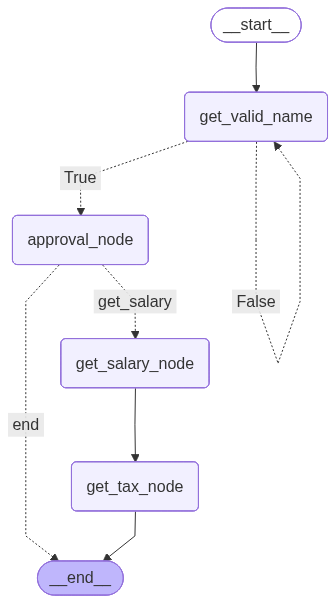

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

Run with approval

In [12]:
result = app.invoke({})
print(result)

Enter an employee name (Tim/Tom/Ann): Tim
Do you give me your approval to retrieve the salary for employee: Tim (y/n)y
{'employee': 'Tim', 'salary': 100000, 'tax': 20000.0, 'approval': 'approved'}


Run with rejection

In [13]:
result = app.invoke({})
print(result)

Enter an employee name (Tim/Tom/Ann): Tom
Do you give me your approval to retrieve the salary for employee: Tom (y/n)n
{'employee': 'Tom', 'approval': 'rejected'}


Run with name validation

In [14]:
result = app.invoke({})
print(result)

Enter an employee name (Tim/Tom/Ann): Joe
Enter an employee name (Tim/Tom/Ann): Peter
Enter an employee name (Tim/Tom/Ann): Ann
Do you give me your approval to retrieve the salary for employee: Ann (y/n)y
{'employee': 'Ann', 'salary': 120000, 'tax': 24000.0, 'approval': 'approved'}
